In [ ]:
import tkinter as tk
from tkinter import ttk, filedialog, messagebox
from datetime import datetime
import pydicom
from pathlib import Path
import matplotlib.pyplot as plt
import os
import napari
import numpy as np
import cv2
import SimpleITK as sitk
import json
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg

from scipy.ndimage import rotate, shift, zoom
from functools import lru_cache


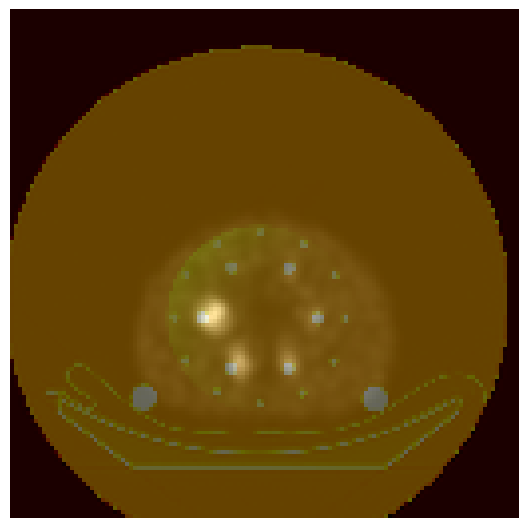

In [ ]:
# --- Variables globales para almacenar archivos ---
archivos_ct = []  # Lista de cortes CT
archivo_spect = ""  # Archivo único SPECT
fig = None # Figura de Matplotlib
ax = None  # Ejes de Matplotlib
canvas = None  # Canvas para incrustar matplotlib en tkinter

ct_pixel_spacing = [1.0, 1.0]   # mm/pixel
spect_pixel_spacing = [1.0, 1.0]

# --- Variables para slices ---
num_slices_spect = 1 # Número total de slices SPECT
num_slices_ct = 1    # Número total de slices CT
slice_spect = None   # Slice actual
slice_ct = None

def seleccionar_fichero(): # Función para seleccionar un archivo SPECT desde el explorador
    global archivo_spect, img_spect, fig, ax, canvas, spect_pixel_spacing, slice_spect, num_slices_spect
    ruta = filedialog.askopenfilename(   # Abre un cuadro de diálogo para seleccionar un archivo de imagen SPECT.
        title="Seleccionar fichero SPECT",
        filetypes=[("Archivos DICOM", "*.dcm")]
    )
    if ruta:
        archivo_spect = ruta
        entry_spect.delete(0, tk.END) # Limpia cualquier ruta de archivo que estuviera allí antes.
        entry_spect.insert(0, ruta) # Inserta el contenido de la variable ruta
        img_spect, spect_pixel_spacing, slice_idx, num_slices_spect = cargar_imagen_dicom(ruta)
        slice_spect.set(slice_idx) # Establece el slice inicial del SPECT

        # Actualizar slider SPECT
        if spect_slider is not None:
            spect_slider.config(to=num_slices_spect-1)

        if fig is None or ax is None or canvas is None: # Crea la figura solo la primera vez y se inserta dentro de TKinter
            fig, ax = plt.subplots(figsize=(5, 5))
            canvas = FigureCanvasTkAgg(fig, master=frame_spect)
            canvas.get_tk_widget().pack(fill="both", expand=True)

            # Fijar límites desde el principio para que no se mueva
            h, w = img_spect[slice_idx].shape if img_spect.ndim==3 else img_spect.shape
            ax.set_xlim(0, w)
            ax.set_ylim(h, 0)
            ax.axis("off")

        actualizar_overlay() #dibuja la superposición SPECT/CT



def seleccionar_ct(): # Función para seleccionar un archivo CT desde el explorador
    global archivos_ct, ct_pixel_spacing, slice_ct, num_slices_ct
    carpeta = filedialog.askdirectory(title="Seleccionar carpeta con cortes CT (.dcm)")
    if carpeta:
        archivos_ct = sorted([os.path.join(carpeta, f) for f in os.listdir(carpeta) if f.lower().endswith(".dcm")])
        if archivos_ct:
            entry_ct.delete(0, tk.END)
            entry_ct.insert(0, carpeta)

            #img_ct, ct_pixel_spacing, slice_idx, num_slices_ct = cargar_pila_ct(archivos_ct)
            #slice_ct.set(slice_idx)

            num_slices_ct = len(archivos_ct)
            slice_ct.set(num_slices_ct // 2)

            # Actualizar slider CT
            if ct_slider is not None:
                ct_slider.config(to=num_slices_ct-1)

            actualizar_overlay() #actualiza la imagen de superposición
        else:
            messagebox.showwarning("Atención", "No se encontraron archivos .dcm en la carpeta seleccionada.")
    
def leer_dicom(ruta): # Lee un archivo DICOM y devuelve información básica.
    try:
        ds = pydicom.dcmread(ruta, stop_before_pixels=True) # (DICOM Read) abre el archivo, lo analiza y carga todos sus datos (metadatos e imagen) en una variable (ds).
        info = [
            f"Nombre del paciente: {getattr(ds, 'PatientName', 'Desconocido')}", # getattr --> lee un campo del DICOM sin que falle si no existe
            f"ID del paciente: {getattr(ds, 'PatientID', 'N/A')}",
            f"Modalidad: {getattr(ds, 'Modality', 'N/A')}",
            f"Dimensiones: {ds.Rows} x {ds.Columns}",
        ]
        return "\n".join(info)
    except Exception as e:
        messagebox.showerror("Error al leer DICOM", f"No se pudo leer el archivo:\n{e}")
        return None

@lru_cache(maxsize=10)
def cargar_slice_ct(ruta):
    ds = pydicom.dcmread(ruta)
    img = ds.pixel_array.astype(np.float32)

    slope = getattr(ds, "RescaleSlope", 1)
    intercept = getattr(ds, "RescaleIntercept", 0)
    img = img * slope + intercept

    vmin, vmax = img.min(), img.max()
    img = (img - vmin) / (vmax - vmin) if vmax > vmin else np.zeros_like(img)

    pixel_spacing = getattr(ds, "PixelSpacing", [1.0, 1.0])
    return img, pixel_spacing
    
def cargar_imagen_dicom(ruta):
    ds = pydicom.dcmread(ruta)
    img = ds.pixel_array.astype(np.float32)

    # Si multiframe (SPECT o CT 3D), guardamos toda la pila
    if img.ndim == 3:
        num_slices = img.shape[0]
        slice_idx = num_slices // 2  # slice central por defecto
        img = img  # mantener toda la pila
    else:
        slice_idx = 0  # solo 2D

    # Corrección CT
    if getattr(ds, "Modality", "") == "CT":
        slope = getattr(ds, "RescaleSlope", 1)
        intercept = getattr(ds, "RescaleIntercept", 0)
        img = img * slope + intercept

    # Normalización
    vmin, vmax = img.min(), img.max()
    if vmax > vmin:
        img = (img - vmin) / (vmax - vmin)
    else:
        img = np.zeros_like(img)

    # PixelSpacing en mm (fila, columna)
    pixel_spacing = getattr(ds, "PixelSpacing", [1.0, 1.0])

    return img, pixel_spacing, slice_idx, img.shape[0] if img.ndim==3 else 1


def guardar_datos(): # Valida y muestra los datos introducidos y DICOMs.
    fecha = entry_fecha.get()
    actividad = entry_actividad.get()

    if not archivo_spect or not archivos_ct or not fecha or not actividad:
        messagebox.showwarning("Campos incompletos", "Por favor, complete todos los campos y seleccione SPECT y CT.")
        return

    # Validar formato de fecha
    try:
        datetime.strptime(fecha, "%d/%m/%Y")
    except ValueError:
        messagebox.showerror("Error de formato", "La fecha debe tener el formato dd/mm/aaaa.")
        return

    # Leer información del SPECT
    info_spect = leer_dicom(archivo_spect)
    if not info_spect:
        return

    # Leer información del primer corte CT como ejemplo
    info_ct = leer_dicom(archivos_ct[0])
    if not info_ct:
        return

    resumen = (
        f"Datos introducidos correctamente\n\n"
        f"Archivo SPECT: {archivo_spect}\n"
        f"Carpeta CT: {entry_ct.get()} ({len(archivos_ct)} cortes)\n"
        f"Fecha: {fecha}\n"
        f"Actividad: {actividad} MBq\n\n"
        f"Información del SPECT:\n{info_spect}\n\n"
        f"Información del primer corte CT:\n{info_ct}"
    )
    messagebox.showinfo("Resumen", resumen)

def mostrar_imagen_dicom(ruta, frame, titulo=""):
    ds = pydicom.dcmread(ruta)
    img = ds.pixel_array.astype(float)

    # SPECT multiframe
    if img.ndim == 3:
        img = img[img.shape[0] // 2]  # corte central

    # Corrección CT
    if getattr(ds, "Modality", "") == "CT":
        slope = getattr(ds, "RescaleSlope", 1)
        intercept = getattr(ds, "RescaleIntercept", 0)
        img = img * slope + intercept

    # Normalización segura
    vmin, vmax = img.min(), img.max()
    if vmax > vmin:
        img = (img - vmin) / (vmax - vmin)
    else:
        img = np.zeros_like(img)

    for widget in frame.winfo_children():
        widget.destroy()

    # Ajustamos la figura para que sea cuadrada o proporcional
    fig, ax = plt.subplots(figsize=(5, 5)) 
    
    # Usar aspect="equal" para mantener proporciones
    ax.imshow(img, cmap="gray", aspect="equal") 
    
    ax.set_title(titulo)
    ax.axis("off")
    
    # Ajusta los márgenes automáticamente para eliminar espacios vacíos
    fig.tight_layout()

    canvas = FigureCanvasTkAgg(fig, master=frame)
    canvas.draw()
    canvas.get_tk_widget().pack(fill="both", expand=True)

    plt.close(fig)

def actualizar_overlay():
    global fig, ax, canvas
    if img_spect is None or not archivos_ct:
        return

    ax.clear()

    # --- Elegir slice actual ---
    if img_spect.ndim == 3:
        img_s = img_spect[slice_spect.get()]
    else:
        img_s = img_spect

    if archivos_ct:
        img_c, ct_pixel_spacing = cargar_slice_ct(archivos_ct[slice_ct.get()])
    else:
        return


    # --- Reescalar CT al tamaño del SPECT ---
    factor_y = img_s.shape[0] / img_c.shape[0]
    factor_x = img_s.shape[1] / img_c.shape[1]
    ct_rescalado = zoom(img_c, (factor_y, factor_x))

    # --- Transformaciones físicas ---
    dx_px = dx_ct.get() * 10 / ct_pixel_spacing[1]  # cm → mm → píxeles
    dy_px = dy_ct.get() * 10 / ct_pixel_spacing[0]
    ct_transformado = rotate(ct_rescalado, rot_ct.get(), reshape=False)
    ct_transformado = shift(ct_transformado, (dy_px, dx_px))

    # --- Dibujar imágenes ---
    h, w = img_s.shape
    extent = [0, w, h, 0]

    ax.imshow(img_s, cmap="gray", extent=extent)
    ax.imshow(ct_transformado, cmap="hot", alpha=0.4, extent=extent)

    # --- Ajustes visuales ---
    ax.set_xlim(0, w)
    ax.set_ylim(h, 0)
    ax.axis("off")

    # --- Refrescar canvas ---
    canvas.draw()



import tkinter as tk
from tkinter import ttk


# CONFIGURACIÓN DE LA VENTANA PRINCIPAL

root = tk.Tk()
root.title("Ingreso de datos SPECT")
root.geometry("1300x700")
root.resizable(False, False)

# variables globales nuevas
img_spect = None
img_ct = None

rot_ct = tk.DoubleVar(value=0)
dx_ct = tk.DoubleVar(value=0)
dy_ct = tk.DoubleVar(value=0)

slice_spect = tk.IntVar(value=0)
slice_ct = tk.IntVar(value=0)

# Entradas tipo pro para ver/escribir valores exactos
entry_rot = None
entry_dx = None
entry_dy = None

# ESTILOS

style = ttk.Style()
style.configure("TLabel", font=("Calibri", 11))
style.configure("TButton", font=("Calibri", 10))
style.configure("TEntry", font=("Calibri", 10))

# FRAMES PRINCIPALES

frame_controles = ttk.Frame(root)
frame_controles.grid(row=0, column=0, sticky="ns", padx=10, pady=10)

frame_spect_container = ttk.LabelFrame(root, text="SPECT/CT")
frame_spect_container.grid(row=0, column=1, sticky="nsew", padx=10, pady=10)

# Configuración del grid principal
root.columnconfigure(0, weight=0)  # Controles
root.columnconfigure(1, weight=1)  # único espacio para SPECT/CT
root.rowconfigure(0, weight=1)


# FRAMES INTERNOS PARA IMÁGENES
frame_spect = ttk.Frame(frame_spect_container)
frame_spect.pack(fill="both", expand=True)

frame_spect_container.config(width=500, height=500)
frame_spect_container.grid_propagate(False)

# CONTROLES DE ENTRADA DE DATOS

# --- Fichero SPECT ---
ttk.Label(frame_controles, text="Fichero SPECT:").grid(row=0, column=0, sticky="w", pady=4)
entry_spect = ttk.Entry(frame_controles, width=35)
entry_spect.grid(row=0, column=1, pady=4)

ttk.Button(frame_controles, text="Examinar...", command=seleccionar_fichero).grid(row=0, column=2, padx=5, pady=4)

# --- Carpeta CT ---
ttk.Label(frame_controles, text="Carpeta CT:").grid(row=1, column=0, sticky="w", pady=4)
entry_ct = ttk.Entry(frame_controles, width=35)
entry_ct.grid(row=1, column=1, pady=4)

ttk.Button(frame_controles, text="Examinar...", command=seleccionar_ct).grid(row=1, column=2, padx=5, pady=4)

# --- Fecha de adquisición ---
ttk.Label(frame_controles, text="Fecha de adquisición (dd/mm/aaaa):").grid(row=2, column=0, sticky="w", pady=4)
entry_fecha = ttk.Entry(frame_controles, width=20)
entry_fecha.grid(row=2, column=1, pady=4, sticky="w")

# --- Actividad ---
ttk.Label(frame_controles, text="Actividad (MBq):").grid(row=3, column=0, sticky="w", pady=4)
entry_actividad = ttk.Entry(frame_controles, width=20)
entry_actividad.grid(row=3, column=1, pady=4, sticky="w")


# BOTONES DE ACCIÓN
ttk.Button(frame_controles, text="Guardar datos", command=guardar_datos).grid(row=4, column=1, pady=12, sticky="w")

# --- Rotación CT ---
ttk.Label(frame_controles, text="Rotación CT (°)").grid(row=5, column=0, sticky="w", pady=4)
rot_slider = ttk.Scale(
    frame_controles, from_=-180, to=180, variable=rot_ct,
    command=lambda e: actualizar_overlay()
)
rot_slider.grid(row=5, column=1, columnspan=2, sticky="ew")
entry_rot = ttk.Entry(frame_controles, width=6, textvariable=rot_ct)
entry_rot.grid(row=5, column=3, padx=5)

# --- Desplazamiento X en cm ---
ttk.Label(frame_controles, text="Desplazamiento X (cm)").grid(row=6, column=0, sticky="w", pady=4)
dx_slider = ttk.Scale(
    frame_controles, from_=-20, to=20, variable=dx_ct,   # ±20 cm
    command=lambda e: actualizar_overlay()
)
dx_slider.grid(row=6, column=1, columnspan=2, sticky="ew")
entry_dx = ttk.Entry(frame_controles, width=6, textvariable=dx_ct)
entry_dx.grid(row=6, column=3, padx=5)

# --- Desplazamiento Y en cm ---
ttk.Label(frame_controles, text="Desplazamiento Y (cm)").grid(row=7, column=0, sticky="w", pady=4)
dy_slider = ttk.Scale(
    frame_controles, from_=-20, to=20, variable=dy_ct,   # ±20 cm
    command=lambda e: actualizar_overlay()
)
dy_slider.grid(row=7, column=1, columnspan=2, sticky="ew")
entry_dy = ttk.Entry(frame_controles, width=6, textvariable=dy_ct)
entry_dy.grid(row=7, column=3, padx=5)

# --- Slice SPECT ---
ttk.Label(frame_controles, text="Slice SPECT").grid(row=8, column=0, sticky="w", pady=4)
spect_slider = ttk.Scale(frame_controles, from_=0, to=num_slices_spect-1, variable=slice_spect,
                         command=lambda e: actualizar_overlay())
spect_slider.grid(row=8, column=1, columnspan=2, sticky="ew")

# --- Slice CT ---
ttk.Label(frame_controles, text="Slice CT").grid(row=9, column=0, sticky="w", pady=4)
ct_slider = ttk.Scale(frame_controles, from_=0, to=num_slices_ct-1, variable=slice_ct,
                     command=lambda e: actualizar_overlay())
ct_slider.grid(row=9, column=1, columnspan=2, sticky="ew")



def on_entry_change(*args):
    actualizar_overlay()

# Vincular los cambios en los entries para que se actualice la imagen
rot_ct.trace_add("write", on_entry_change)
dx_ct.trace_add("write", on_entry_change)
dy_ct.trace_add("write", on_entry_change)


# EJECUCIÓN DE LA APLICACIÓN
root.mainloop()


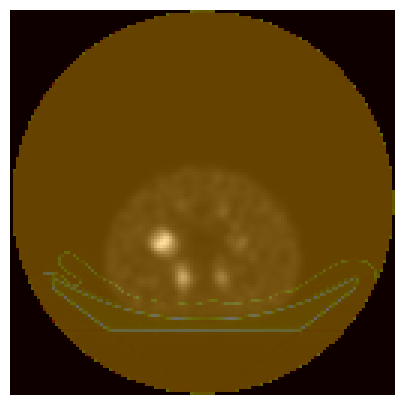

In [4]:
import os
import numpy as np
import pydicom
import tkinter as tk
from tkinter import ttk, filedialog, messagebox
from datetime import datetime
from functools import lru_cache

import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg

from scipy.ndimage import zoom, rotate, shift


# --- Variables globales ---
archivos_ct = []
archivo_spect = ""

fig = None
ax = None
canvas = None

ct_pixel_spacing = [1.0, 1.0]
spect_pixel_spacing = [1.0, 1.0]

num_slices_spect = 1
num_slices_ct = 1

img_spect = None


# =========================================================
# ================== CARGA DE DICOM =======================
# =========================================================

def cargar_imagen_dicom(ruta):
    ds = pydicom.dcmread(ruta)
    img = ds.pixel_array.astype(np.float32)

    if img.ndim == 3:
        num_slices = img.shape[0]
        slice_idx = num_slices // 2
    else:
        slice_idx = 0

    if getattr(ds, "Modality", "") == "CT":
        slope = getattr(ds, "RescaleSlope", 1)
        intercept = getattr(ds, "RescaleIntercept", 0)
        img = img * slope + intercept

    vmin, vmax = img.min(), img.max()
    img = (img - vmin) / (vmax - vmin) if vmax > vmin else np.zeros_like(img)

    pixel_spacing = getattr(ds, "PixelSpacing", [1.0, 1.0])

    return img, pixel_spacing, slice_idx, img.shape[0] if img.ndim == 3 else 1


@lru_cache(maxsize=10)
def cargar_slice_ct(ruta):
    ds = pydicom.dcmread(ruta)
    img = ds.pixel_array.astype(np.float32)

    slope = getattr(ds, "RescaleSlope", 1)
    intercept = getattr(ds, "RescaleIntercept", 0)
    img = img * slope + intercept

    vmin, vmax = img.min(), img.max()
    img = (img - vmin) / (vmax - vmin) if vmax > vmin else np.zeros_like(img)

    pixel_spacing = getattr(ds, "PixelSpacing", [1.0, 1.0])
    return img, pixel_spacing


def leer_dicom(ruta):
    try:
        ds = pydicom.dcmread(ruta)
        info = [
            f"Nombre del paciente: {getattr(ds, 'PatientName', 'Desconocido')}",
            f"ID del paciente: {getattr(ds, 'PatientID', 'N/A')}",
            f"Modalidad: {getattr(ds, 'Modality', 'N/A')}",
            f"Dimensiones: {ds.Rows} x {ds.Columns}",
        ]
        return "\n".join(info)
    except Exception as e:
        messagebox.showerror("Error", str(e))
        return None


# =========================================================
# ================== SELECCIÓN ARCHIVOS ===================
# =========================================================

def seleccionar_fichero():
    global archivo_spect, img_spect, spect_pixel_spacing, num_slices_spect

    ruta = filedialog.askopenfilename(
        title="Seleccionar fichero SPECT",
        filetypes=[("Archivos DICOM", "*.dcm")]
    )

    if not ruta:
        return

    archivo_spect = ruta
    entry_spect.delete(0, tk.END)
    entry_spect.insert(0, ruta)

    img_spect, spect_pixel_spacing, slice_idx, num_slices_spect = cargar_imagen_dicom(ruta)
    slice_spect.set(slice_idx)

    spect_slider.config(to=num_slices_spect - 1)

    crear_figura()
    actualizar_overlay()


def seleccionar_ct():
    global archivos_ct, num_slices_ct

    carpeta = filedialog.askdirectory(title="Seleccionar carpeta CT")
    if not carpeta:
        return

    archivos_ct = sorted(
        [os.path.join(carpeta, f) for f in os.listdir(carpeta) if f.lower().endswith(".dcm")]
    )

    if not archivos_ct:
        messagebox.showwarning("Aviso", "No hay DICOMs CT en la carpeta")
        return

    entry_ct.delete(0, tk.END)
    entry_ct.insert(0, carpeta)

    num_slices_ct = len(archivos_ct)
    slice_ct.set(num_slices_ct // 2)
    ct_slider.config(to=num_slices_ct - 1)

    actualizar_overlay()


# =========================================================
# ================== OVERLAY ==============================
# =========================================================

def crear_figura():
    global fig, ax, canvas

    if fig is None:
        fig, ax = plt.subplots(figsize=(5, 5))
        canvas = FigureCanvasTkAgg(fig, master=frame_spect)
        canvas.get_tk_widget().pack(fill="both", expand=True)
        ax.axis("off")


def actualizar_overlay():
    if img_spect is None or not archivos_ct:
        return

    ax.clear()

    img_s = img_spect[slice_spect.get()] if img_spect.ndim == 3 else img_spect
    img_c, ct_pixel_spacing = cargar_slice_ct(archivos_ct[slice_ct.get()])

    fy = img_s.shape[0] / img_c.shape[0]
    fx = img_s.shape[1] / img_c.shape[1]
    img_c = zoom(img_c, (fy, fx))

    dx_px = dx_ct.get() * 10 / ct_pixel_spacing[1]
    dy_px = dy_ct.get() * 10 / ct_pixel_spacing[0]

    img_c = rotate(img_c, rot_ct.get(), reshape=False)
    img_c = shift(img_c, (dy_px, dx_px))

    h, w = img_s.shape
    extent = [0, w, h, 0]

    ax.imshow(img_s, cmap="gray", extent=extent)
    ax.imshow(img_c, cmap="hot", alpha=0.4, extent=extent)

    ax.set_xlim(0, w)
    ax.set_ylim(h, 0)
    ax.axis("off")

    canvas.draw()


# =========================================================
# ================== GUARDAR DATOS ========================
# =========================================================

def guardar_datos():
    fecha = entry_fecha.get()
    actividad = entry_actividad.get()

    if not archivo_spect or not archivos_ct or not fecha or not actividad:
        messagebox.showwarning("Error", "Campos incompletos")
        return

    try:
        datetime.strptime(fecha, "%d/%m/%Y")
    except ValueError:
        messagebox.showerror("Error", "Formato fecha incorrecto")
        return

    info_spect = leer_dicom(archivo_spect)
    info_ct = leer_dicom(archivos_ct[0])

    resumen = f"""
Archivo SPECT: {archivo_spect}
Carpeta CT: {entry_ct.get()} ({len(archivos_ct)} cortes)
Fecha: {fecha}
Actividad: {actividad} MBq

SPECT:
{info_spect}

CT:
{info_ct}
"""
    messagebox.showinfo("Resumen", resumen)


# =========================================================
# ================== UI ===================================
# =========================================================

root = tk.Tk()
root.title("Ingreso de datos SPECT")
root.geometry("1300x700")
root.resizable(False, False)

rot_ct = tk.DoubleVar(value=0)
dx_ct = tk.DoubleVar(value=0)
dy_ct = tk.DoubleVar(value=0)

slice_spect = tk.IntVar(value=0)
slice_ct = tk.IntVar(value=0)

frame_controles = ttk.Frame(root)
frame_controles.grid(row=0, column=0, padx=10, pady=10)

frame_spect_container = ttk.LabelFrame(root, text="SPECT / CT")
frame_spect_container.grid(row=0, column=1, padx=10, pady=10)

frame_spect = ttk.Frame(frame_spect_container)
frame_spect.pack(fill="both", expand=True)

# Entradas
ttk.Label(frame_controles, text="Fichero SPECT").grid(row=0, column=0)
entry_spect = ttk.Entry(frame_controles, width=35)
entry_spect.grid(row=0, column=1)
ttk.Button(frame_controles, text="Examinar", command=seleccionar_fichero).grid(row=0, column=2)

ttk.Label(frame_controles, text="Carpeta CT").grid(row=1, column=0)
entry_ct = ttk.Entry(frame_controles, width=35)
entry_ct.grid(row=1, column=1)
ttk.Button(frame_controles, text="Examinar", command=seleccionar_ct).grid(row=1, column=2)

ttk.Label(frame_controles, text="Fecha").grid(row=2, column=0)
entry_fecha = ttk.Entry(frame_controles)
entry_fecha.grid(row=2, column=1)

ttk.Label(frame_controles, text="Actividad (MBq)").grid(row=3, column=0)
entry_actividad = ttk.Entry(frame_controles)
entry_actividad.grid(row=3, column=1)

ttk.Button(frame_controles, text="Guardar", command=guardar_datos).grid(row=4, column=1)

spect_slider = ttk.Scale(frame_controles, from_=0, to=0, variable=slice_spect,
                         command=lambda e: actualizar_overlay())
spect_slider.grid(row=5, column=1, sticky="ew")

ct_slider = ttk.Scale(frame_controles, from_=0, to=0, variable=slice_ct,
                      command=lambda e: actualizar_overlay())
ct_slider.grid(row=6, column=1, sticky="ew")

root.mainloop()


In [ ]:
def load_dicom_folder(path):
    reader = sitk.ImageSeriesReader()
    dicom_names = reader.GetGDCMSeriesFileNames(path)
    reader.SetFileNames(dicom_names)
    image = reader.Execute()
    return image

In [9]:
ct_path = r"C:\Users\gervi\OneDrive - Universidad Complutense de Madrid (UCM)\MASTER\SEGUNDO CUATRI\TFM\Imagenes prueba\CT"

ct = load_dicom_folder(ct_path)
print(ct.GetSize())
print(ct.GetSpacing())
print(ct.GetOrigin())

(512, 512, 606)
(0.976562, 0.976562, 1.25)
(-250.0, -250.0, -378.35)


VISOR NAPARI PARA SPECT

In [3]:
# --- Cargar el DICOM ---
file_path = r"C:\Users\gervi\OneDrive - Universidad Complutense de Madrid (UCM)\MASTER\SEGUNDO CUATRI\TFM\Imagenes prueba\Tomo4FOV_Lu177peak_IRACSC001_DS.dcm"
ds = pydicom.dcmread(file_path)
image = ds.pixel_array.astype(float)

# --- Lanzar visor ---
viewer = napari.view_image(image, name="Lu-177 Tomografía", colormap='gray', contrast_limits=[0, np.max(image)])
napari.run()

C:\Users\gervi\AppData\Local\Temp\ipykernel_32564\1818084049.py:7: FutureWarning: `napari.view_image` is deprecated and will be removed in napari 0.7.0.
Use `viewer = napari.Viewer(); viewer.add_image(...)` instead.
  viewer = napari.view_image(image, name="Lu-177 Tomografía", colormap='gray', contrast_limits=[0, np.max(image)])


VISOR NAPARI PARA CT

In [7]:
# --- Carpeta con los DICOM ---
folder = r"C:\Users\gervi\OneDrive - Universidad Complutense de Madrid (UCM)\MASTER\SEGUNDO CUATRI\TFM\Imagenes prueba\CT"

# --- Leer todos los archivos .dcm y ordenarlos (opcional: por nombre o por SliceLocation) ---
dicom_files = [f for f in os.listdir(folder) if f.endswith(".dcm")]
dicom_files.sort()  # si los nombres siguen el orden de los cortes

# --- Cargar los DICOM y extraer arrays ---
slices = []
for f in dicom_files:
    ds = pydicom.dcmread(os.path.join(folder, f))
    slices.append(ds.pixel_array.astype(float))

# --- Apilar en un array 3D (Z, Y, X) ---
image_3d = np.stack(slices, axis=0)

# --- Lanzar visor 3D en Napari ---
viewer = napari.view_image(
    image_3d, 
    name="Lu-177 Tomografía", 
    colormap='gray', 
    contrast_limits=[0, np.max(image_3d)]
)
napari.run()

C:\Users\gervi\AppData\Local\Temp\ipykernel_30204\2111650818.py:18: FutureWarning: `napari.view_image` is deprecated and will be removed in napari 0.7.0.
Use `viewer = napari.Viewer(); viewer.add_image(...)` instead.
  viewer = napari.view_image(
